# Pipeline A — Step 3: Decision Support for Banking Policy (2026)

Retrain FD model on ALL data (2021-2025), then forecast 2026 under 3 scenarios.

**Outputs:** Dashboard-ready CSVs in `pipeline_A/output/`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / 'pipeline_A' / 'output' / 'A1_annual_panel.csv').exists(): ROOT = p; break

out = ROOT / 'pipeline_A' / 'output'
df = pd.read_csv(out / 'A1_annual_panel.csv')
df = df.sort_values(['provinsi_id','tahun']).reset_index(drop=True)
df['x5_internet'] = df.groupby('provinsi_id')['x5_internet'].transform(lambda s: s.bfill())
print(f'Loaded: {len(df)} rows, {df["provinsi_id"].nunique()} provinces')

Loaded: 124 rows, 31 provinces


In [2]:
# === Build First-Differences from ALL data ===
econ_cols = ['x1_bi_rate_avg','x2_inflasi_avg','log_pdrb',
             'x4_tpt','x5_internet','x8_ldr','x9_npl','x10_umkm']

frames = []
for pid, g in df.groupby('provinsi_id'):
    g = g.sort_values('tahun')
    d = pd.DataFrame()
    d['provinsi_id'] = g['provinsi_id'].iloc[1:].values
    d['nama_provinsi'] = g['nama_provinsi'].iloc[1:].values
    d['tahun'] = g['tahun'].iloc[1:].values
    d['y_level'] = g['twp90_avg'].iloc[1:].values
    d['y_prev'] = g['twp90_avg'].iloc[:-1].values
    d['dy'] = d['y_level'] - d['y_prev']
    for c in econ_cols:
        d[f'd_{c}'] = g[c].iloc[1:].values - g[c].iloc[:-1].values
    frames.append(d)

df_fd = pd.concat(frames, ignore_index=True).dropna().reset_index(drop=True)
dx_cols = [f'd_{c}' for c in econ_cols]

X = df_fd[dx_cols].astype(float)
y = df_fd['dy'].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = HuberRegressor(epsilon=1.35)
model.fit(X_scaled, y)

r2 = model.score(X_scaled, y)
print(f'Trained on {len(X)} obs, {X.shape[1]} features, R2={r2:.4f}')
print(f'Intercept: {model.intercept_:.6f}')

Trained on 93 obs, 8 features, R2=0.1280
Intercept: -0.000779


In [3]:
# === 2025 actual values (anchor for 2026 forecast) ===
latest = df[df['tahun']==2025][['provinsi_id','nama_provinsi','twp90_avg'] + econ_cols].copy()
latest = latest.rename(columns={'twp90_avg': 'twp90_2025'}).reset_index(drop=True)
n_prov = len(latest)

# === 3 Scenarios: each defines delta from 2025 values ===
scenarios = {
    'Baseline': {c: 0.0 for c in econ_cols},
    'Stress_NPL_Up': {
        'x1_bi_rate_avg': 0.5, 'x2_inflasi_avg': 0.005,
        'log_pdrb': 0.02, 'x4_tpt': 0.3, 'x5_internet': 0.01,
        'x8_ldr': -0.02, 'x9_npl': 0.01, 'x10_umkm': -0.01
    },
    'Optimistic_Recovery': {
        'x1_bi_rate_avg': -0.5, 'x2_inflasi_avg': -0.003,
        'log_pdrb': 0.05, 'x4_tpt': -0.5, 'x5_internet': 0.02,
        'x8_ldr': 0.03, 'x9_npl': -0.005, 'x10_umkm': 0.01
    }
}

# === Forecast each scenario ===
all_forecasts = []
for sname, deltas in scenarios.items():
    # Build scenario X: same delta for all provinces
    X_scen_raw = pd.DataFrame([[deltas[c] for c in econ_cols]] * n_prov, columns=dx_cols)
    X_scen_scaled = scaler.transform(X_scen_raw)
    
    dy_pred = model.predict(X_scen_scaled)
    fc = latest[['provinsi_id','nama_provinsi','twp90_2025']].copy()
    fc['scenario'] = sname
    fc['delta_pred'] = dy_pred
    fc['twp90_2026_pred'] = (fc['twp90_2025'] + fc['delta_pred']).clip(lower=0)
    fc['pct_change'] = (fc['delta_pred'] / fc['twp90_2025'] * 100).round(2)
    all_forecasts.append(fc)

forecasts = pd.concat(all_forecasts, ignore_index=True)
print(f'Generated {len(forecasts)} forecasts ({n_prov} provinces x {len(scenarios)} scenarios)')

Generated 93 forecasts (31 provinces x 3 scenarios)


In [4]:
# === Risk Classification ===
baseline_fc = forecasts[forecasts['scenario']=='Baseline'].copy().reset_index(drop=True)
stress_fc = forecasts[forecasts['scenario']=='Stress_NPL_Up'].copy().reset_index(drop=True)

risk_levels = []
for i in range(len(baseline_fc)):
    twp = baseline_fc.loc[i, 'twp90_2025']
    stress_twp = stress_fc.loc[i, 'twp90_2026_pred']
    if twp > 0.03 or stress_twp > 0.04:
        risk_levels.append('HIGH')
    elif twp > 0.02 or stress_twp > 0.03:
        risk_levels.append('MEDIUM')
    else:
        risk_levels.append('LOW')

baseline_fc['risk_level'] = risk_levels
baseline_fc['twp90_stress'] = stress_fc['twp90_2026_pred'].values
baseline_fc['stress_delta_pct'] = ((baseline_fc['twp90_stress'] - baseline_fc['twp90_2025'])
                                    / baseline_fc['twp90_2025'] * 100).round(2)

def recommend(row):
    if row['risk_level'] == 'HIGH':
        return 'Intensifkan pengawasan kredit; batasi ekspansi pinjaman baru; tingkatkan cadangan CKPN'
    elif row['risk_level'] == 'MEDIUM':
        return 'Monitor NPL bulanan; evaluasi kualitas portofolio kredit; siapkan early intervention'
    else:
        return 'Pertahankan kebijakan saat ini; peluang ekspansi kredit UMKM'

baseline_fc['rekomendasi'] = baseline_fc.apply(recommend, axis=1)
baseline_fc = baseline_fc.sort_values('twp90_2025', ascending=False).reset_index(drop=True)

print('Risk distribution:')
print(baseline_fc['risk_level'].value_counts().to_string())
print()
display(baseline_fc[['nama_provinsi','twp90_2025','risk_level','twp90_stress','stress_delta_pct','rekomendasi']].head(10))

Risk distribution:
risk_level
LOW       19
MEDIUM     8
HIGH       4



,nama_provinsi,twp90_2025,risk_level,twp90_stress,stress_delta_pct,rekomendasi
0,Dki Jakarta,0.046683,HIGH,0.044423,-4.84,Intensifkan pengawasan kredit; batasi ekspansi...
1,Nusa Tenggara Barat,0.040408,HIGH,0.038148,-5.59,Intensifkan pengawasan kredit; batasi ekspansi...
2,Jawa Timur,0.034067,HIGH,0.031806,-6.64,Intensifkan pengawasan kredit; batasi ekspansi...
3,Jawa Barat,0.033583,HIGH,0.031323,-6.73,Intensifkan pengawasan kredit; batasi ekspansi...
4,Daerah Istimewa Yogyakarta,0.028625,MEDIUM,0.026365,-7.90,Monitor NPL bulanan; evaluasi kualitas portofo...
5,Sumatera Selatan,0.028517,MEDIUM,0.026256,-7.93,Monitor NPL bulanan; evaluasi kualitas portofo...
6,Jawa Tengah,0.028242,MEDIUM,0.025981,-8.00,Monitor NPL bulanan; evaluasi kualitas portofo...
7,Lampung,0.027750,MEDIUM,0.025490,-8.15,Monitor NPL bulanan; evaluasi kualitas portofo...
8,Sumatera Barat,0.026108,MEDIUM,0.023848,-8.66,Monitor NPL bulanan; evaluasi kualitas portofo...
9,Banten,0.024117,MEDIUM,0.021856,-9.37,Monitor NPL bulanan; evaluasi kualitas portofo...


In [5]:
# === Key Driver Summary ===
interpretasi_map = {
    'x1_bi_rate_avg': 'Kenaikan BI rate -> penurunan TWP90 (kebijakan moneter ketat)',
    'x2_inflasi_avg': 'Kenaikan inflasi -> penurunan TWP90 (erosi daya beli)',
    'log_pdrb': 'Pertumbuhan PDRB -> kenaikan TWP90 (ekonomi ekspansif)',
    'x4_tpt': 'Kenaikan pengangguran -> kenaikan TWP90',
    'x5_internet': 'Peningkatan internet -> kenaikan TWP90 (akses digital banking)',
    'x8_ldr': 'Kenaikan LDR -> kenaikan TWP90 (ekspansi kredit)',
    'x9_npl': 'Kenaikan NPL -> penurunan TWP90 (pengetatan kredit oleh bank)',
    'x10_umkm': 'Kenaikan rasio UMKM -> penurunan TWP90',
}

drivers = pd.DataFrame({
    'faktor_ekonomi': econ_cols,
    'koefisien': (model.coef_ / scaler.scale_).round(6),
    'interpretasi': [interpretasi_map.get(c, '') for c in econ_cols]
})

print('=== Economic Drivers ===')
display(drivers)

=== Economic Drivers ===


,faktor_ekonomi,koefisien,interpretasi
0,x1_bi_rate_avg,-0.001652,Kenaikan BI rate -> penurunan TWP90 (kebijakan...
1,x2_inflasi_avg,-0.105687,Kenaikan inflasi -> penurunan TWP90 (erosi day...
2,log_pdrb,-0.002526,Pertumbuhan PDRB -> kenaikan TWP90 (ekonomi ek...
3,x4_tpt,-0.000365,Kenaikan pengangguran -> kenaikan TWP90
4,x5_internet,0.005376,Peningkatan internet -> kenaikan TWP90 (akses ...
5,x8_ldr,0.001181,Kenaikan LDR -> kenaikan TWP90 (ekspansi kredit)
6,x9_npl,-0.132012,Kenaikan NPL -> penurunan TWP90 (pengetatan kr...
7,x10_umkm,0.007968,Kenaikan rasio UMKM -> penurunan TWP90


In [6]:
# === SAVE DASHBOARD CSVs ===
# 1. Province Risk Dashboard
risk_dash = baseline_fc[['provinsi_id','nama_provinsi','twp90_2025',
    'risk_level','twp90_stress','stress_delta_pct','rekomendasi']].copy()
risk_dash.columns = ['provinsi_id','nama_provinsi','twp90_aktual_2025',
    'level_risiko','twp90_skenario_stress','perubahan_stress_pct','rekomendasi_kebijakan']
risk_dash.to_csv(out / 'A3_province_risk_dashboard.csv', index=False)

# 2. Scenario Comparison
scen_wide = forecasts.pivot_table(
    index=['provinsi_id','nama_provinsi','twp90_2025'],
    columns='scenario', values='twp90_2026_pred'
).reset_index()
scen_wide.columns.name = None
scen_wide.to_csv(out / 'A3_scenario_comparison.csv', index=False)

# 3. Economic Drivers
drivers.to_csv(out / 'A3_economic_drivers.csv', index=False)

# 4. Full forecasts
forecasts.to_csv(out / 'A3_full_forecasts.csv', index=False)

# 5. Model metadata
pd.DataFrame([{
    'model': 'First-Differences Huber Regression',
    'training_period': '2022-2025 (annual diffs)',
    'n_observations': len(X),
    'epsilon': 1.35,
    'r_squared': round(r2, 4),
    'caveat': 'Koefisien = asosiasi bukan kausalitas. Gunakan untuk ranking dan arah, bukan target numerik.'
}]).to_csv(out / 'A3_model_metadata.csv', index=False)

print('=== Dashboard CSVs Saved ===')
for f in sorted(out.glob('A3_*.csv')):
    print(f'  {f.name} ({f.stat().st_size:,} bytes)')

=== Dashboard CSVs Saved ===
  A3_economic_drivers.csv (629 bytes)
  A3_full_forecasts.csv (9,094 bytes)
  A3_model_metadata.csv (233 bytes)
  A3_province_risk_dashboard.csv (4,361 bytes)
  A3_scenario_comparison.csv (3,058 bytes)


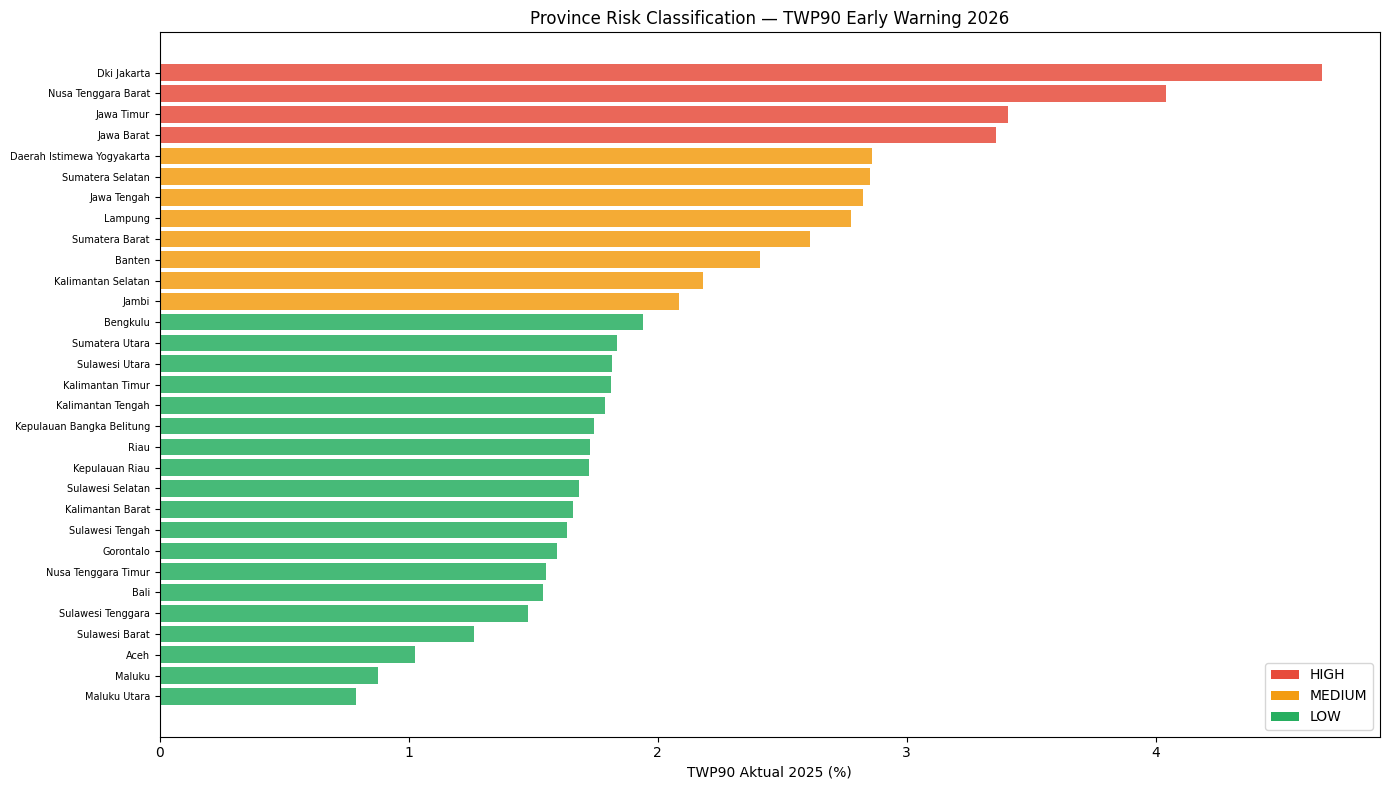

In [7]:
# === VIZ: Province Risk Classification ===
risk_colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#27ae60'}
rd = risk_dash.sort_values('twp90_aktual_2025', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
colors = [risk_colors[r] for r in rd['level_risiko']]
ax.barh(range(len(rd)), rd['twp90_aktual_2025']*100, color=colors, alpha=0.85)
ax.set_yticks(range(len(rd)))
ax.set_yticklabels(rd['nama_provinsi'], fontsize=7)
ax.set_xlabel('TWP90 Aktual 2025 (%)')
ax.set_title('Province Risk Classification — TWP90 Early Warning 2026')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=risk_colors[r], label=f'{r}') for r in ['HIGH','MEDIUM','LOW']],
          loc='lower right')
fig.tight_layout()
fig.savefig(out / 'A3_risk_classification.png', dpi=150, bbox_inches='tight')
plt.show()

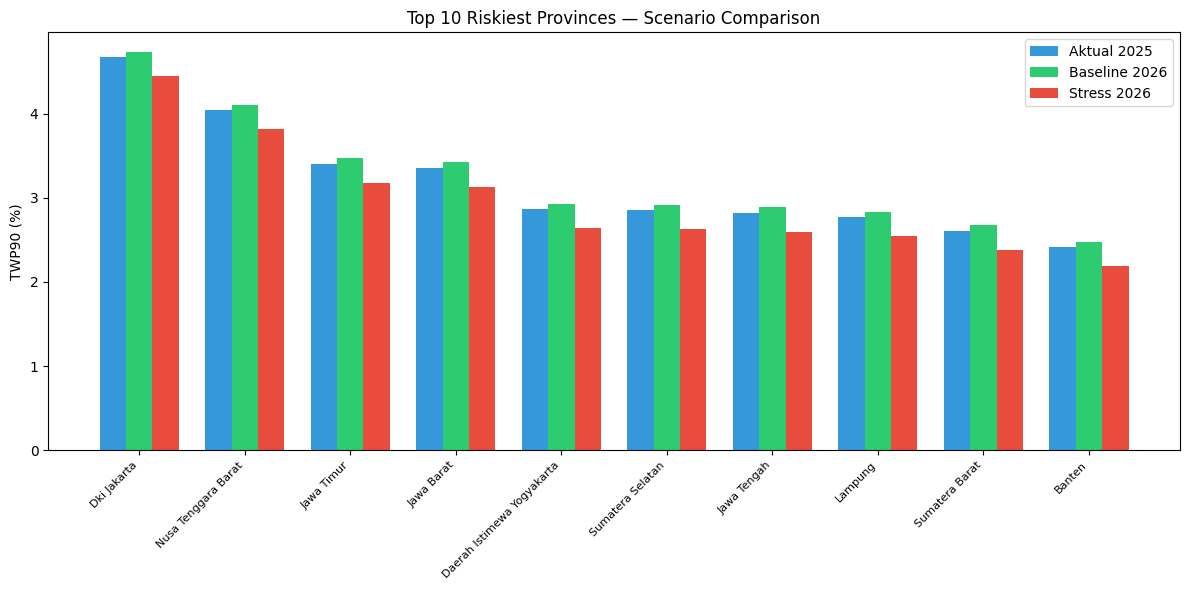

In [8]:
# === VIZ: Scenario Comparison (Top 10) ===
top10 = scen_wide.nlargest(10, 'Stress_NPL_Up')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10)); w = 0.25
ax.bar(x - w, top10['twp90_2025']*100, w, label='Aktual 2025', color='#3498db')
ax.bar(x,     top10['Baseline']*100,    w, label='Baseline 2026', color='#2ecc71')
ax.bar(x + w, top10['Stress_NPL_Up']*100, w, label='Stress 2026', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(top10['nama_provinsi'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('TWP90 (%)')
ax.set_title('Top 10 Riskiest Provinces — Scenario Comparison')
ax.legend(); fig.tight_layout()
fig.savefig(out / 'A3_scenario_top10.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('='*70)
print('PIPELINE A - DECISION SUPPORT COMPLETE')
print('='*70)
for lvl in ['HIGH','MEDIUM','LOW']:
    n = (risk_dash['level_risiko']==lvl).sum()
    provs = risk_dash[risk_dash['level_risiko']==lvl]['nama_provinsi'].tolist()
    print(f'{lvl}: {n} provinces - {", ".join(provs[:5])}{"..." if len(provs)>5 else ""}')
print(f'\nKey driver: NPL (only significant predictor, p<0.05)')
print(f'Dashboard files: {len(list(out.glob("A3_*")))} outputs saved to {out}')
print(f'\nCAVEAT: Gunakan untuk RANKING & ARAH, bukan target numerik presisi.')

PIPELINE A - DECISION SUPPORT COMPLETE
HIGH: 4 provinces - Dki Jakarta, Nusa Tenggara Barat, Jawa Timur, Jawa Barat
MEDIUM: 8 provinces - Daerah Istimewa Yogyakarta, Sumatera Selatan, Jawa Tengah, Lampung, Sumatera Barat...
LOW: 19 provinces - Bengkulu, Sumatera Utara, Sulawesi Utara, Kalimantan Timur, Kalimantan Tengah...

Key driver: NPL (only significant predictor, p<0.05)
Dashboard files: 7 outputs saved to C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output

CAVEAT: Gunakan untuk RANKING & ARAH, bukan target numerik presisi.
